# Distancias y medidas de similitud

> Cómo medir lo "parecidas" que son dos observaciones: distancias para datos numéricos (euclídea, Manhattan, Mahalanobis), para direcciones (coseno), para datos binarios y categóricos (Hamming, Jaccard) y para datos mixtos (Gower). Son la base de k-NN, del clustering y de la imputación por vecinos.
>
> **Requisitos previos:** [Transformación de datos](03-transformacion-datos.ipynb) (escalado) · **Relacionado:** [Reducción de dimensionalidad](../04-machine-learning/02-reduccion-dimensionalidad.ipynb), [k-NN](../04-machine-learning/07-knn.ipynb)

## 1. Idea clave

Muchos métodos se basan en una sola pregunta: **¿qué observaciones se parecen?** k-NN clasifica según los vecinos más cercanos, k-means y el clustering jerárquico agrupan puntos próximos, la imputación kNN rellena huecos con los registros más parecidos, y t-SNE o UMAP conservan vecindarios.

La respuesta depende por completo de **cómo se mide la distancia**, y no hay una distancia universal:

- en variables numéricas influyen la **escala** de cada variable y sus **correlaciones**;
- en textos o *embeddings* suele importar la **dirección** del vector más que su longitud;
- en datos binarios (presencia/ausencia) importa lo que **comparten**, no los miles de ceros comunes;
- con variables de distintos tipos hay que **combinarlas** de forma equilibrada.

Elegir la distancia es una decisión de modelado tan importante como elegir el algoritmo.

## 2. Conceptos importantes

### 2.1. Qué es una distancia

Una función $d(\mathbf{x}, \mathbf{y})$ es una **distancia** (o métrica) si, para cualesquiera observaciones $\mathbf{x}$, $\mathbf{y}$, $\mathbf{z}$, cumple:

1. **No negatividad**: $d(\mathbf{x}, \mathbf{y}) \geq 0$, y $d(\mathbf{x}, \mathbf{y}) = 0$ solo si $\mathbf{x} = \mathbf{y}$.
2. **Simetría**: $d(\mathbf{x}, \mathbf{y}) = d(\mathbf{y}, \mathbf{x})$.
3. **Desigualdad triangular**: $d(\mathbf{x}, \mathbf{z}) \leq d(\mathbf{x}, \mathbf{y}) + d(\mathbf{y}, \mathbf{z})$: el camino directo nunca es más largo que dar un rodeo.

Una **similitud** $s$ mide lo contrario: es mayor cuanto más se parecen. Muchas se convierten en disimilitud con $d = 1 - s$. Algunas de estas "distancias" (como la de coseno) no cumplen la desigualdad triangular. Funcionan en la práctica, pero ciertos algoritmos que la necesitan para acelerar las búsquedas no pueden usarlas.

### 2.2. Variables numéricas: la familia de Minkowski

Para $\mathbf{x}, \mathbf{y} \in \mathbb{R}^p$ (con $p$ variables):

$$
d_q(\mathbf{x}, \mathbf{y}) = \left(\sum_{j=1}^{p} |x_j - y_j|^q\right)^{1/q}
$$

| $q$ | Nombre | Fórmula | Idea |
|---|---|---|---|
| 1 | **Manhattan** (*city block*) | $\sum_j \lvert x_j - y_j\rvert$ | Distancia recorriendo "manzanas": suma de diferencias |
| 2 | **Euclídea** | $\sqrt{\sum_j (x_j - y_j)^2}$ | La distancia "en línea recta" |
| $\infty$ | **Chebyshev** | $\max_j \lvert x_j - y_j\rvert$ | Solo cuenta la mayor diferencia |

Todas **dependen de la escala**: la variable con mayor rango domina. La **distancia euclídea estandarizada** (o de Gauss) divide cada diferencia por la desviación típica $\sigma_j$ de la variable, lo que equivale a estandarizar antes:

$$
d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{j=1}^{p}\left(\frac{x_j - y_j}{\sigma_j}\right)^2}
$$

### 2.3. Distancia de Mahalanobis

Estandarizar corrige las escalas, pero no las **correlaciones**. Si dos variables están muy correlacionadas (altura y peso), la euclídea cuenta dos veces la misma información, y una combinación "rara" de valores normales pasa desapercibida. La distancia de Mahalanobis usa la matriz de covarianzas $\Sigma$ de los datos:

$$
d_M(\mathbf{x}, \mathbf{y}) = \sqrt{(\mathbf{x} - \mathbf{y})^\top\, \Sigma^{-1}\, (\mathbf{x} - \mathbf{y})}
$$

- Si las variables son incorreladas, coincide con la euclídea estandarizada.
- Si además tienen varianza 1, coincide con la euclídea.

Mide la distancia en "número de desviaciones típicas" **en la dirección** en la que se separan los puntos. Por eso detecta atípicos multivariantes (ver [limpieza de datos](02-limpieza-datos.ipynb#2.3.-Detectar-valores-atípicos)).

### 2.4. Direcciones: similitud del coseno

La **similitud del coseno** mide el ángulo $\theta$ entre dos vectores, sin importar su longitud:

$$
s_{\cos}(\mathbf{x}, \mathbf{y}) = \cos\theta = \frac{\mathbf{x} \cdot \mathbf{y}}{\lVert\mathbf{x}\rVert\,\lVert\mathbf{y}\rVert}, \qquad d_{\cos} = 1 - s_{\cos}
$$

donde $\mathbf{x}\cdot\mathbf{y} = \sum_j x_j y_j$ es el producto escalar y $\lVert\mathbf{x}\rVert$ la norma (longitud) euclídea. Es la opción habitual para **textos** (vectores de frecuencias de palabras) y **embeddings**: dos documentos sobre el mismo tema apuntan en la misma dirección aunque uno sea mucho más largo.

Si los vectores están **normalizados** ($\lVert\mathbf{x}\rVert = \lVert\mathbf{y}\rVert = 1$), la euclídea y el coseno están ligados por

$$
\lVert\mathbf{x} - \mathbf{y}\rVert^2 = 2\,(1 - s_{\cos}(\mathbf{x}, \mathbf{y}))
$$

y ordenan los vecinos exactamente igual.

### 2.5. Datos binarios y categóricos: Hamming y Jaccard

Para vectores de presencia/ausencia (1/0), como los ingredientes de una receta o los productos de una cesta de la compra:

- **Hamming**: número (o proporción) de posiciones en las que difieren. Cuenta igual una coincidencia de unos que una de ceros.
- **Jaccard**: compara los conjuntos $A$ y $B$ de elementos presentes:

$$
J(A, B) = \frac{|A \cap B|}{|A \cup B|}, \qquad d_J = 1 - J(A, B)
$$

  **Ignora los ceros compartidos**. Si hay 1.000 ingredientes posibles y cada receta usa 5, dos recetas cualesquiera coinciden en casi todos los ceros. Hamming las verá casi idénticas, mientras que Jaccard solo mira los ingredientes que realmente usan.

Para categóricas con más de dos valores, Hamming cuenta las variables en las que las categorías difieren (equivale a la coincidencia simple).

### 2.6. Datos mixtos: distancia de Gower

Con variables numéricas y categóricas a la vez, la **distancia de Gower** calcula una distancia parcial $d_j \in [0, 1]$ para cada variable y las promedia:

- numéricas: $d_j = \dfrac{|x_j - y_j|}{R_j}$, donde $R_j$ es el rango (máximo − mínimo) de la variable;
- categóricas: $d_j = 0$ si coinciden y $1$ si no.

Además, admite valores perdidos: la variable se excluye del promedio para ese par.

### 2.7. La maldición de la dimensionalidad

Al aumentar el número de dimensiones, las distancias entre puntos aleatorios se **concentran**: el vecino más cercano y el más lejano quedan casi a la misma distancia, y "cercano" deja de significar algo. Es una de las razones para [reducir la dimensionalidad](../04-machine-learning/02-reduccion-dimensionalidad.ipynb) o [seleccionar atributos](../04-machine-learning/03-seleccion-atributos.ipynb) antes de usar métodos basados en distancias. En alta dimensión, Manhattan suele conservar algo más de contraste que la euclídea.

## 3. Código

Usamos el conjunto **wine** de scikit-learn (178 vinos de 3 variedades, 13 medidas químicas en unidades muy distintas), que procede del repositorio UCI. Para los casos con correlaciones, textos, datos binarios y mixtos creamos pequeños ejemplos en el propio código.

### 3.1. Qué significa "cerca" según la distancia

Los puntos a distancia 1 del origen forman una "circunferencia" distinta para cada distancia de Minkowski:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import hamming, jaccard, mahalanobis, euclidean
from sklearn.datasets import load_wine
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

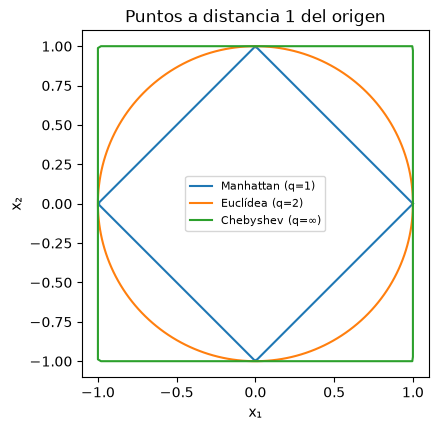

In [2]:
angulos = np.linspace(0, 2 * np.pi, 400)
direcciones = np.c_[np.cos(angulos), np.sin(angulos)]

fig, ax = plt.subplots(figsize=(4.5, 4.5))
for q, nombre in [(1, "Manhattan (q=1)"), (2, "Euclídea (q=2)"), (np.inf, "Chebyshev (q=∞)")]:
    # escalar cada dirección para que su norma q valga 1
    normas = np.linalg.norm(direcciones, ord=q, axis=1)
    ax.plot(*(direcciones / normas[:, None]).T, label=nombre)
ax.set_aspect("equal")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_title("Puntos a distancia 1 del origen")
ax.legend(fontsize=8, loc="center")
plt.show()

Para Manhattan, "cerca" es un rombo; para la euclídea, un círculo; para Chebyshev, un cuadrado. El mismo punto puede ser vecino con una distancia y no con otra.

### 3.2. El efecto de la escala

En *wine*, la prolina toma valores de cientos, mientras que otras variables (como el tono) están entre 0,5 y 1,7. Comparamos k-NN con varias distancias, con y sin estandarizar, con validación cruzada:

In [3]:
X_wine, y_wine = load_wine(return_X_y=True, as_frame=True)
print(X_wine[["proline", "hue", "alcohol"]].agg(["min", "max", "std"]).round(2))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
modelos = {
    "euclídea, sin escalar": KNeighborsClassifier(metric="euclidean"),
    "euclídea, escalando": make_pipeline(StandardScaler(), KNeighborsClassifier(metric="euclidean")),
    "Manhattan, escalando": make_pipeline(StandardScaler(), KNeighborsClassifier(metric="manhattan")),
    "Chebyshev, escalando": make_pipeline(StandardScaler(), KNeighborsClassifier(metric="chebyshev")),
    "coseno, escalando": make_pipeline(StandardScaler(), KNeighborsClassifier(metric="cosine")),
}
pd.Series({n: cross_val_score(m, X_wine, y_wine, cv=cv).mean() for n, m in modelos.items()},
          name="exactitud k-NN").round(3).to_frame()

     proline   hue  alcohol
min   278.00  0.48    11.03
max  1680.00  1.71    14.83
std   314.91  0.23     0.81


,exactitud k-NN
"euclídea, sin escalar",0.680
"euclídea, escalando",0.972
"Manhattan, escalando",0.966
"Chebyshev, escalando",0.933
"coseno, escalando",0.972


Sin escalar, la distancia es casi solo "diferencia de prolina", y k-NN acierta un 68 %. Al estandarizar (equivalente a la distancia euclídea estandarizada), todas las variables cuentan, y la exactitud sube al 97 %. Con las variables ya escaladas, la elección entre euclídea, Manhattan o coseno cambia poco. Chebyshev, que solo mira la mayor diferencia, es la que peor funciona.

### 3.3. Mahalanobis: cuando las variables están correlacionadas

Generamos datos de dos variables con correlación 0,9 y comparamos dos puntos:
- **A** está lejos del centro pero **en la dirección** de la correlación (valores altos en ambas variables, algo habitual);
- **B** está más cerca del centro, pero **contra** la correlación (alto en una variable y bajo en la otra, algo raro).

In [4]:
rng = np.random.default_rng(42)
nube = rng.multivariate_normal(mean=[0, 0], cov=[[1, 0.9], [0.9, 1]], size=500)
centro = nube.mean(axis=0)
cov_inv = np.linalg.inv(np.cov(nube, rowvar=False))

A, B = np.array([2.0, 2.0]), np.array([1.0, -1.0])
pd.DataFrame({
    "euclídea al centro": [euclidean(p, centro) for p in (A, B)],
    "Mahalanobis al centro": [mahalanobis(p, centro, cov_inv) for p in (A, B)],
}, index=["A (a favor de la correlación)", "B (contra la correlación)"]).round(2)

,euclídea al centro,Mahalanobis al centro
A (a favor de la correlación),2.8,2.08
B (contra la correlación),1.4,4.54


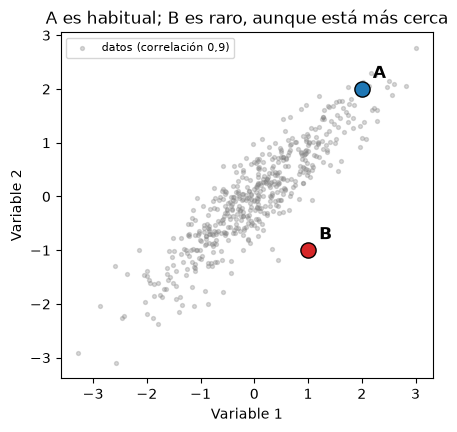

In [5]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(*nube.T, s=8, alpha=0.3, color="gray", label="datos (correlación 0,9)")
for p, nombre, color in [(A, "A", "tab:blue"), (B, "B", "tab:red")]:
    ax.scatter(*p, s=120, color=color, edgecolor="black", zorder=3)
    ax.annotate(nombre, p, xytext=(8, 8), textcoords="offset points", fontsize=12, weight="bold")
ax.set_aspect("equal")
ax.set_xlabel("Variable 1")
ax.set_ylabel("Variable 2")
ax.set_title("A es habitual; B es raro, aunque está más cerca")
ax.legend(loc="upper left", fontsize=8)
plt.show()

Según la euclídea, B (1,4) está más cerca del centro que A (2,8). Según Mahalanobis es al revés: B está a 4,5 "desviaciones típicas en su dirección" y A a solo 2,1. Mirando el gráfico, B es claramente el punto atípico.

### 3.4. Textos: coseno frente a euclídea

Tres documentos breves, representados con TF-IDF (frecuencia de cada palabra ponderada por su rareza). El tercero es el primero **repetido tres veces**:

In [6]:
documentos = [
    "el modelo predice la gravedad del accidente",
    "la receta lleva harina huevos y azúcar",
    "el modelo predice la gravedad del accidente " * 3,
]
tfidf = TfidfVectorizer(norm=None).fit_transform(documentos)  # sin normalizar, para ver el efecto

nombres = ["doc 1 (modelo)", "doc 2 (receta)", "doc 3 (= doc 1 ×3)"]
print("Distancia euclídea:")
print(pd.DataFrame(pairwise_distances(tfidf, metric="euclidean"), index=nombres, columns=nombres).round(2))
print("\nSimilitud del coseno:")
print(pd.DataFrame(cosine_similarity(tfidf), index=nombres, columns=nombres).round(2))

Distancia euclídea:
                    doc 1 (modelo)  doc 2 (receta)  doc 3 (= doc 1 ×3)
doc 1 (modelo)                0.00            4.93                6.62
doc 2 (receta)                4.93            0.00               10.39
doc 3 (= doc 1 ×3)            6.62           10.39                0.00

Similitud del coseno:
                    doc 1 (modelo)  doc 2 (receta)  doc 3 (= doc 1 ×3)
doc 1 (modelo)                1.00            0.08                1.00
doc 2 (receta)                0.08            1.00                0.08
doc 3 (= doc 1 ×3)            1.00            0.08                1.00


- Para la euclídea, el documento 3 está **más lejos** del documento 1 (que dice exactamente lo mismo) que el documento 2, que habla de otra cosa. La longitud del texto domina.
- Para el coseno, los documentos 1 y 3 son **idénticos** (similitud 1), y el 2 apenas se parece a los otros (similitud 0,08, solo por compartir la palabra "la"). Mide el tema, no la longitud.

Por eso, en textos y *embeddings* se usa el coseno, o la euclídea sobre vectores **normalizados**, que es equivalente (ver 2.4).

### 3.5. Datos binarios: Hamming frente a Jaccard

Tres recetas descritas por 1.000 ingredientes posibles (1 = lo usa):
- la receta 1 usa los ingredientes 0, 1 y 2;
- la receta 2 usa los ingredientes 0, 1 y 3 (comparte 2 de 3 con la receta 1);
- la receta 3 usa 10 ingredientes, ninguno en común con la 1.

In [7]:
n_ingredientes = 1000
receta_1 = np.zeros(n_ingredientes, dtype=bool)
receta_2 = np.zeros(n_ingredientes, dtype=bool)
receta_3 = np.zeros(n_ingredientes, dtype=bool)
receta_1[[0, 1, 2]] = True
receta_2[[0, 1, 3]] = True
receta_3[10:20] = True

filas = {}
for nombre, otra in [("receta 1 vs 2 (comparten 2)", receta_2), ("receta 1 vs 3 (no comparten)", receta_3)]:
    filas[nombre] = {
        # scipy devuelve la proporción de posiciones distintas
        "Hamming (proporción)": hamming(receta_1, otra),
        "coincidencia simple (1 − Hamming)": 1 - hamming(receta_1, otra),
        "distancia de Jaccard": jaccard(receta_1, otra),
    }
pd.DataFrame(filas).T.round(3)

,Hamming (proporción),coincidencia simple (1 − Hamming),distancia de Jaccard
receta 1 vs 2 (comparten 2),0.002,0.998,0.5
receta 1 vs 3 (no comparten),0.013,0.987,1.0


Según la **coincidencia simple** (1 − Hamming), las tres recetas son casi idénticas (0,998 y 0,987), porque coinciden en los cientos de ingredientes que **ninguna** usa. **Jaccard** solo mira los ingredientes presentes: las recetas 1 y 2 están a 0,5 (comparten la mitad de los ingredientes que usan entre las dos) y las 1 y 3 a 1 (nada en común). Para presencia/ausencia dispersa, Jaccard es la distancia adecuada.

### 3.6. Datos mixtos: distancia de Gower

Ni scikit-learn ni SciPy incluyen la distancia de Gower. Es fácil de implementar para verla por dentro:

In [8]:
pasajeros = pd.DataFrame({
    "edad": [22, 38, 26, 80],
    "tarifa": [7.25, 71.28, 7.93, 30.00],
    "sexo": ["hombre", "mujer", "mujer", "hombre"],
    "clase": ["3.ª", "1.ª", "3.ª", "1.ª"],
}, index=["P1", "P2", "P3", "P4"])

def gower(df):
    """Matriz de distancias de Gower: media de distancias parciales en [0, 1]."""
    parciales = []
    for col in df.columns:
        v = df[col].to_numpy()
        if np.issubdtype(v.dtype, np.number):
            rango = v.max() - v.min()
            parciales.append(np.abs(v[:, None] - v[None, :]) / rango)
        else:
            parciales.append((v[:, None] != v[None, :]).astype(float))
    return pd.DataFrame(np.mean(parciales, axis=0), index=df.index, columns=df.index)

print(pasajeros)
gower(pasajeros).round(2)

    edad  tarifa    sexo clase
P1    22    7.25  hombre   3.ª
P2    38   71.28   mujer   1.ª
P3    26    7.93   mujer   3.ª
P4    80   30.00  hombre   1.ª


,P1,P2,P3,P4
P1,0.00,0.82,0.27,0.59
P2,0.82,0.00,0.55,0.59
P3,0.27,0.55,0.00,0.82
P4,0.59,0.59,0.82,0.00


P1 y P3 (jóvenes de 3.ª clase con tarifas casi iguales) son los más parecidos (0,27): solo difieren en el sexo y en 4 años de edad. Cada variable aporta como mucho 1/4 de la distancia, sea cual sea su escala original. Esa es la idea de Gower: **equilibrar** variables de tipos y escalas distintas.

### 3.7. La maldición de la dimensionalidad

Tomamos 500 puntos aleatorios uniformes en $d$ dimensiones y medimos, desde uno de ellos, el **contraste relativo** entre el vecino más lejano y el más cercano, $(d_{\max} - d_{\min}) / d_{\min}$:

In [9]:
filas = []
for d in [2, 10, 100, 1000]:
    puntos = rng.random((500, d))
    for metrica in ["euclidean", "manhattan"]:
        dist = pairwise_distances(puntos[:1], puntos[1:], metric=metrica)[0]
        filas.append({"dimensiones": d, "distancia": metrica,
                      "contraste": (dist.max() - dist.min()) / dist.min()})

contraste = pd.DataFrame(filas).pivot(index="dimensiones", columns="distancia", values="contraste")
contraste.round(3)

distancia,euclidean,manhattan
dimensiones,,
2,50.824,56.946
10,3.332,4.313
100,0.410,0.474
1000,0.103,0.129


Con 2 dimensiones, el vecino más lejano está decenas de veces más lejos que el más cercano. Con 1.000, solo alrededor de un 10 % más lejos: **todos los puntos están casi a la misma distancia**. Manhattan conserva algo más de contraste que la euclídea en alta dimensión, pero ninguna escapa al problema.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Dónde | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `KNeighborsClassifier`, `NearestNeighbors`, `DBSCAN` | `metric` | Distancia usada | `"euclidean"`, `"manhattan"`, `"cosine"`, `"jaccard"`… (ver `DistanceMetric`) |
| | `p` | Exponente de Minkowski | `p=1` Manhattan, `p=2` euclídea |
| | `metric_params` | Parámetros de la distancia | Mahalanobis necesita `{"VI": inversa_de_la_covarianza}` o `{"V": covarianza}` |
| `scipy.spatial.distance` | `pdist`, `cdist` | Distancias por pares | `hamming` devuelve la **proporción** de posiciones distintas; `jaccard` espera vectores booleanos |
| `scipy.cluster.hierarchy.linkage` | `method`, `metric` | Enlace y distancia | `method="ward"` solo es válido con distancia euclídea |
| `TfidfVectorizer` | `norm` | Normalizar cada documento | `"l2"` por defecto: con vectores normalizados, euclídea y coseno ordenan igual |
| `umap.UMAP`, `TSNE` | `metric` | Distancia en el espacio original | Coseno para *embeddings*; Jaccard para datos binarios |

### 4.2. Errores comunes

Varias de estas lecciones salen de un análisis real de recetas de cocina: se agruparon a partir de *embeddings* de su texto (vectores de 384 dimensiones) y a partir de una matriz binaria de ingredientes.

**1. No escalar antes de usar distancias.** Es el error más frecuente y el más caro: en *wine*, k-NN pasa del 68 % al 97 % solo por estandarizar (3.2). Cualquier método basado en distancias (k-NN, k-means, clustering jerárquico, DBSCAN, imputación kNN) necesita variables en escalas comparables.

**2. Usar euclídea o coseno con datos binarios dispersos.** Para la matriz de ingredientes (una columna por ingrediente, casi todo ceros), las distancias que cuentan los ceros compartidos hacen que todas las recetas parezcan similares. La conclusión del análisis fue que la **distancia de Jaccard**, que solo mira los ingredientes presentes, es la adecuada (3.5). El mismo razonamiento vale para cestas de la compra, etiquetas o síntomas.

**3. Cambiar de distancia entre pasos sin comprobar que son equivalentes.** En el análisis de *embeddings*, la visualización con UMAP y el clustering jerárquico usaban la distancia coseno, pero el clustering con HDBSCAN usaba la euclídea. Aquí no había contradicción: el modelo que generaba esos *embeddings* (`all-MiniLM-L6-v2`) incluye un paso de normalización y devuelve vectores de longitud 1, y con vectores normalizados la euclídea y el coseno ordenan igual. Pero con vectores sin normalizar, cambiar de distancia entre pasos significa que la visualización y el agrupamiento miden cosas distintas. Comprueba la norma de los vectores o usa la misma distancia en todo el flujo:

In [10]:
# Con vectores normalizados: ||x - y||² = 2 (1 - cos)
x, y = rng.normal(size=384), rng.normal(size=384)
x, y = x / np.linalg.norm(x), y / np.linalg.norm(y)
print(f"||x - y||²       = {np.sum((x - y) ** 2):.4f}")
print(f"2 · (1 - cos)    = {2 * (1 - x @ y):.4f}")

||x - y||²       = 2.0612
2 · (1 - cos)    = 2.0612


**4. Combinar la distancia con un método que no la admite.** El enlace de Ward del clustering jerárquico minimiza la varianza dentro de los grupos, y solo tiene sentido con distancia euclídea. En el análisis de clustering jerárquico sobre conjuntos sintéticos, Ward se usó correctamente con la euclídea. Para *embeddings* con coseno se eligió el enlace medio (*average*), que sí admite cualquier distancia. De forma parecida, k-means minimiza distancias euclídeas al cuadrado: con otra distancia hay que usar variantes como k-medoids.

**5. Mahalanobis con pocas observaciones o variables redundantes.** Necesita invertir la matriz de covarianzas. Si hay más variables que observaciones, o variables perfectamente correlacionadas (por ejemplo, todas las columnas one-hot de una misma categoría), la matriz no es invertible y el cálculo falla o da resultados inestables. Reduce o selecciona variables antes, o usa un estimador robusto de la covarianza.

**6. Confiar en los vecinos en alta dimensión.** Con cientos de variables, las distancias se concentran (3.7) y los "vecinos más cercanos" apenas son más cercanos que el resto. Reduce la dimensionalidad o selecciona variables antes de usar métodos basados en distancias, y valida con un modelo si los vecindarios tienen sentido.

## 5. Comparación con métodos relacionados

| Distancia | Tipo de datos | Sensible a la escala | Tiene en cuenta correlaciones | Cuándo usarla |
|---|---|---|---|---|
| **Euclídea** | Numéricos | Sí (escalar antes) | No | Opción por defecto con variables escaladas; la que asumen k-means y Ward |
| **Manhattan** | Numéricos | Sí | No | Algo más robusta a atípicos; conserva más contraste en alta dimensión |
| **Chebyshev** | Numéricos | Sí | No | Cuando importa la peor diferencia (tolerancias, control de calidad) |
| **Euclídea estandarizada** | Numéricos | No | No | Variables en unidades distintas; equivale a estandarizar y usar la euclídea |
| **Mahalanobis** | Numéricos | No | **Sí** | Variables correlacionadas; atípicos multivariantes; requiere covarianza invertible |
| **Coseno** | Vectores (textos, *embeddings*) | No (ignora la longitud) | No | Cuando importa la dirección y no la magnitud |
| **Hamming** | Binarios o categóricos | — | No | Vectores de longitud fija donde coincidir en 0 también significa parecido |
| **Jaccard** | Binarios dispersos (conjuntos) | — | No | Presencia/ausencia: ingredientes, cestas, etiquetas |
| **Gower** | Mixtos (numéricos + categóricos) | No (usa rangos) | No | Tablas con variables de distintos tipos, admite perdidos |

## 6. Referencias

### Fuentes

- scikit-learn: [`DistanceMetric`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html) (nombres de distancias y parámetros), [*Pairwise metrics, Affinities and Kernels*](https://scikit-learn.org/stable/modules/metrics.html) (coseno) y [`TfidfVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).
- SciPy: [`scipy.spatial.distance`](https://docs.scipy.org/doc/scipy/reference/spatial.distance.html) (distancias para vectores numéricos y booleanos).
- Dataset: [wine en scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html), procedente del conjunto *Wine* del repositorio UCI.

### Para saber más

- Deza, M. M. y Deza, E. (2016). *Encyclopedia of Distances* (4.ª ed.). Springer. Catálogo de referencia de distancias y similitudes para todo tipo de datos.
- Aggarwal, C. C., Hinneburg, A. y Keim, D. A. (2001). *On the Surprising Behavior of Distance Metrics in High Dimensional Space*. En *Database Theory — ICDT 2001*, LNCS 1973, 420–434. Springer. Cómo se comportan las distancias de Minkowski en alta dimensión y por qué Manhattan suele ir mejor que la euclídea.